In [1]:
import numpy as np
import math as m
from numpy import arange as arange
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D


dt     = 1 # size of a time step [ms]
t_sim  = 1000 # simulation time [ms] 
time = arange(0,t_sim,dt)

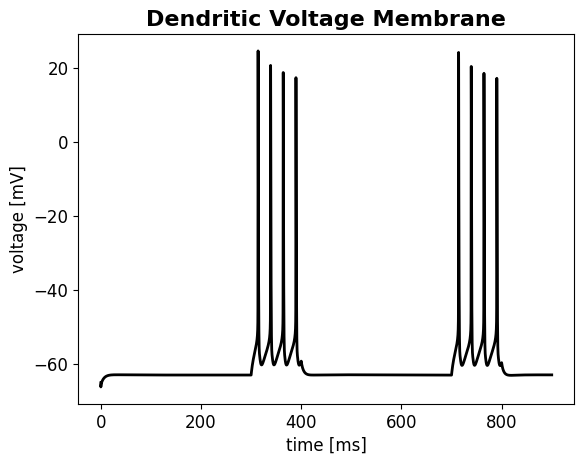

In [2]:
plt.rcParams.update({'font.size': 12})
vm = np.loadtxt('data/01_grc_vm.txt')
plt.plot(vm[:,0],vm[:,1], 'k', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('voltage [mV]')

plt.title('Dendritic Voltage Membrane', fontsize=16,fontweight ='bold')

plt.show()

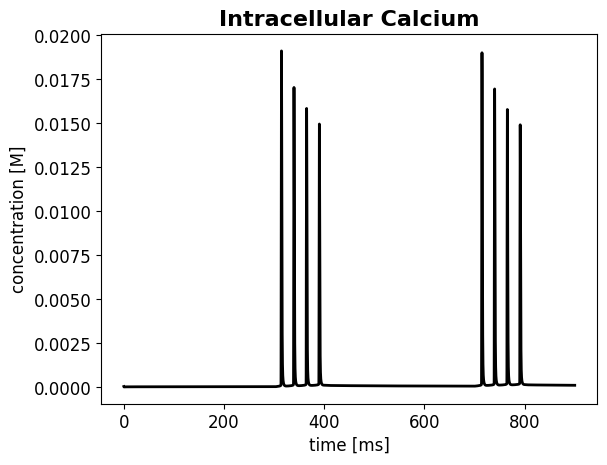

In [3]:
Cai = np.loadtxt('data/04_grc_cai.txt')
plt.plot(Cai[:,0],Cai[:,1], 'k', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('concentration [M]')
plt.title('Intracellular Calcium', fontsize=16,fontweight ='bold')
plt.show()

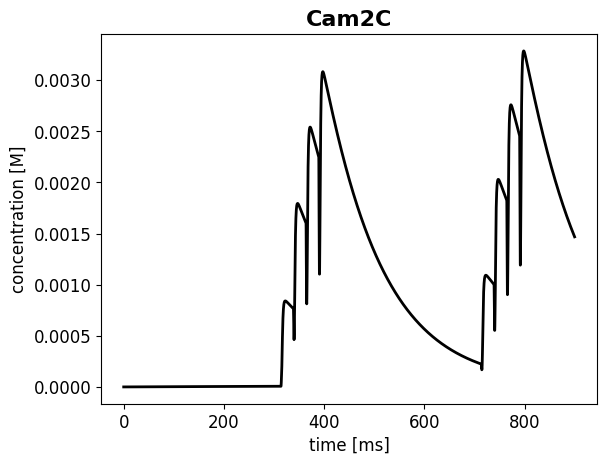

In [4]:
CAM2C = np.loadtxt('data/05_grc_CAM2C.txt')
plt.plot(CAM2C[:,0], CAM2C[:,1], 'k', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('concentration [M]')
plt.title('Cam2C', fontsize=16,fontweight ='bold')
plt.show()

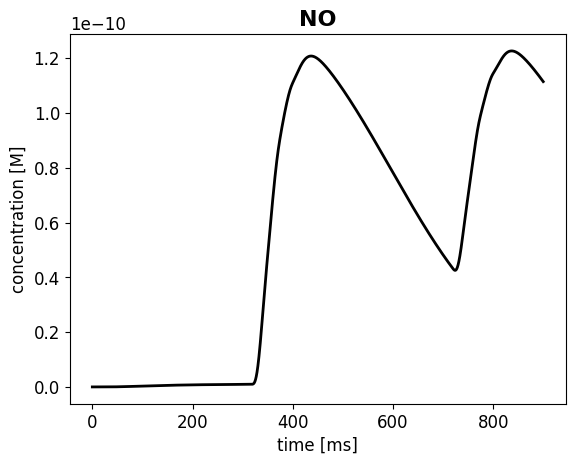

In [5]:
NO = np.loadtxt('data/03_grc_no.txt')
plt.plot(NO[:,0],NO[:,1],  'k',linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('concentration [M]')
plt.title('NO', fontsize=16,fontweight ='bold')
plt.show()

In [6]:
import numpy as np
import math as m
from numpy import arange as arange
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D


#production function
tau = -150
tauNOS1 = 200
tauNOS2 = 25
A = 1.35e-9

dt     = 1 # size of a time step [ms]
t_sim  = 1000 # simulation time [ms] 
time = arange(0,t_sim,dt)

spike = np.zeros((len(time)))
spike[315]=1
spike[340]=1
spike[365]=1
spike[390]=1
spike[715]=1
spike[740]=1
spike[765]=1
spike[790]=1

Ca = np.zeros((len(time)))
nNOS = np.zeros((len(time)))

for i in range(1,t_sim,1):
    #production equations
    Ca[i] = Ca[i-1] + (((Ca[i-1]/tau) + spike[i-1])*dt)
    nNOS[i] = nNOS[i-1]+((((1/tauNOS1)*((Ca[i-1])/((Ca[i-1])+1)))-(nNOS[i-1]/tauNOS2))*dt)

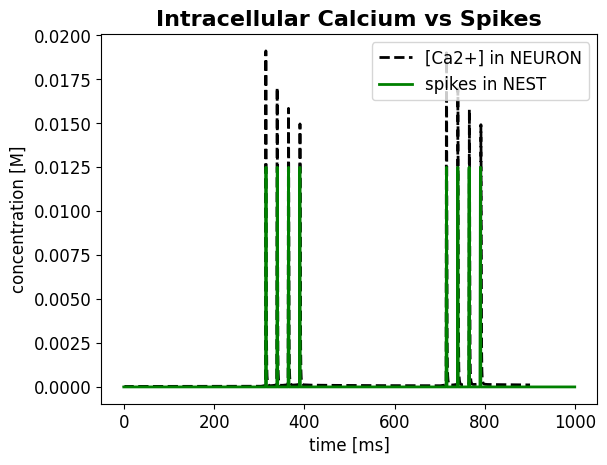

In [7]:
plt.rcParams.update({'font.size': 12})
Cai = np.loadtxt('data/04_grc_cai.txt')
plt.plot(Cai[:,0],Cai[:,1], '--k', linewidth=2, label = '[Ca2+] in NEURON')
plt.plot(spike*0.0125,'g',  linewidth=2, label = 'spikes in NEST')
plt.xlabel('time [ms]')
plt.ylabel('concentration [M]')
plt.title('Intracellular Calcium vs Spikes', fontsize=16,fontweight ='bold')
plt.legend()
plt.show()


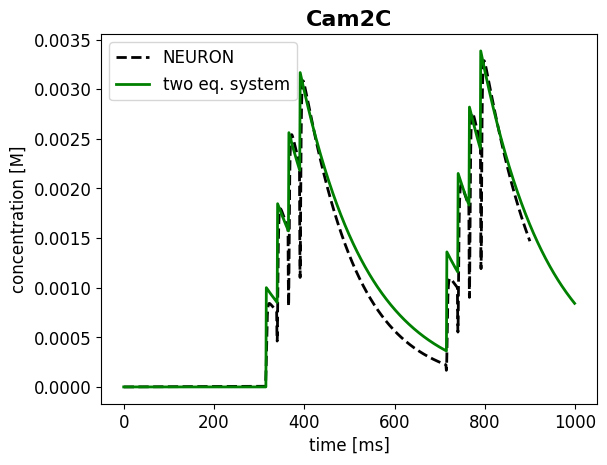

In [9]:
CAM2C = np.loadtxt('data/05_grc_CAM2C.txt')
plt.plot(CAM2C[:,0], CAM2C[:,1], '--k', linewidth=2, label = 'NEURON')
plt.plot(Ca*1e-3,'g',  linewidth=2, label = 'two eq. system')
plt.xlabel('time [ms]')
plt.ylabel('concentration [M]')
plt.title('Cam2C', fontsize=16,fontweight ='bold')
plt.legend()
plt.show()

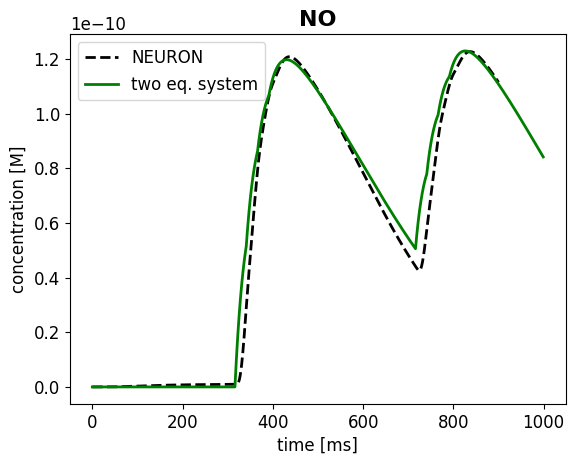

In [10]:
NO = np.loadtxt('data/03_grc_no.txt')
plt.plot(NO[:,0],NO[:,1], '--k' ,linewidth=2, label = 'NEURON')
plt.plot(nNOS*A, 'g',linewidth=2, label = 'two eq. system')
plt.xlabel('time [ms]')
plt.ylabel('concentration [M]')
plt.title('NO', fontsize=16,fontweight ='bold')
plt.legend()
plt.show()